# Network Intrusion Detection - Week 4-5
## Step 2: Model Training, Comparison & Evaluation

**Project:** M.Sc. Applied Computer Science - SRH University Heidelberg  
**Author:** Atharva Gajbe

---
### What this notebook covers
1. Load preprocessed NSL-KDD data
2. Train 6 classifiers: Logistic Regression, Naive Bayes, KNN, Decision Tree, Random Forest, SVM
3. Evaluate each with accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix
4. Compare models and select the best performer (recall-weighted, since false negatives are costly)
5. 5-fold cross-validation on the best model
6. Save the best model + metadata for the Streamlit prototype

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, os, json, warnings
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROC_DIR   = '../data/processed/'
MODEL_DIR  = '../models/'
FIG_DIR    = '../outputs/figures/'
OUT_DIR    = '../outputs/'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 1. Load Preprocessed Data

In [2]:
X_train = np.load(PROC_DIR + 'X_train.npy')
y_train = np.load(PROC_DIR + 'y_train.npy')
X_test  = np.load(PROC_DIR + 'X_test.npy')
y_test  = np.load(PROC_DIR + 'y_test.npy')
feature_cols = pd.read_csv(PROC_DIR + 'feature_columns.csv')['0'].tolist()

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

X_train: (125973, 41), y_train: (125973,)
X_test:  (22544, 41),  y_test:  (22544,)
Features (41): ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## 2. Define Models

Baseline (Logistic Regression, Naive Bayes, KNN), tree-based (Decision Tree, Random Forest), and SVM, as outlined in the project plan.

In [3]:
MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Naive Bayes':         GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
}
print(f'{len(MODELS)} models defined:', list(MODELS.keys()))

6 models defined: ['Logistic Regression', 'Naive Bayes', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest', 'SVM (RBF)']


## 3. Train & Evaluate All Models

SVM on the full 126k-row training set is slow with an RBF kernel, so we train it on a stratified subsample for tractability while keeping the other models on the full set.

In [4]:
from sklearn.model_selection import train_test_split

# Subsample for SVM only (RBF kernel scales poorly beyond ~20k rows)
SVM_SAMPLE_SIZE = 20000
if X_train.shape[0] > SVM_SAMPLE_SIZE:
    X_train_svm, _, y_train_svm, _ = train_test_split(
        X_train, y_train, train_size=SVM_SAMPLE_SIZE,
        stratify=y_train, random_state=RANDOM_STATE
    )
else:
    X_train_svm, y_train_svm = X_train, y_train

print(f'SVM will train on {X_train_svm.shape[0]} rows (subsampled from {X_train.shape[0]})')

SVM will train on 20000 rows (subsampled from 125973)


In [5]:
results = []
trained_models = {}
roc_data = {}

for name, model in MODELS.items():
    print(f'Training {name}...')
    t0 = time.time()

    if name == 'SVM (RBF)':
        model.fit(X_train_svm, y_train_svm)
    else:
        model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc,
        'Train Time (s)': round(train_time, 2)
    })
    trained_models[name] = model
    roc_data[name] = roc_curve(y_test, y_proba)

    print(f'  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  ROC-AUC={auc:.4f}  ({train_time:.1f}s)')

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

Training Logistic Regression...


  Accuracy=0.7539  Precision=0.9256  Recall=0.6173  F1=0.7407  ROC-AUC=0.8974  (0.5s)
Training Naive Bayes...
  Accuracy=0.7708  Precision=0.9160  Recall=0.6578  F1=0.7657  ROC-AUC=0.8397  (0.1s)
Training K-Nearest Neighbors...


  Accuracy=0.7763  Precision=0.9734  Recall=0.6241  F1=0.7606  ROC-AUC=0.8358  (0.0s)
Training Decision Tree...


  Accuracy=0.7961  Precision=0.9241  Recall=0.6993  F1=0.7961  ROC-AUC=0.7790  (0.6s)
Training Random Forest...


  Accuracy=0.7785  Precision=0.9660  Recall=0.6332  F1=0.7650  ROC-AUC=0.9628  (2.7s)
Training SVM (RBF)...


  Accuracy=0.7653  Precision=0.9690  Recall=0.6070  F1=0.7465  ROC-AUC=0.9013  (6.6s)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,Decision Tree,0.796132,0.924107,0.699291,0.796132,0.778998,0.64
1,Naive Bayes,0.770848,0.916007,0.657757,0.765693,0.839653,0.09
2,Random Forest,0.778522,0.966001,0.633211,0.764980,0.962835,2.71
3,K-Nearest Neighbors,0.776304,0.973384,0.624094,0.760553,0.835849,0.03
4,SVM (RBF),0.765259,0.969026,0.607029,0.746455,0.901330,6.57
5,Logistic Regression,0.753903,0.925575,0.617315,0.740651,0.897374,0.54


## 4. Model Comparison

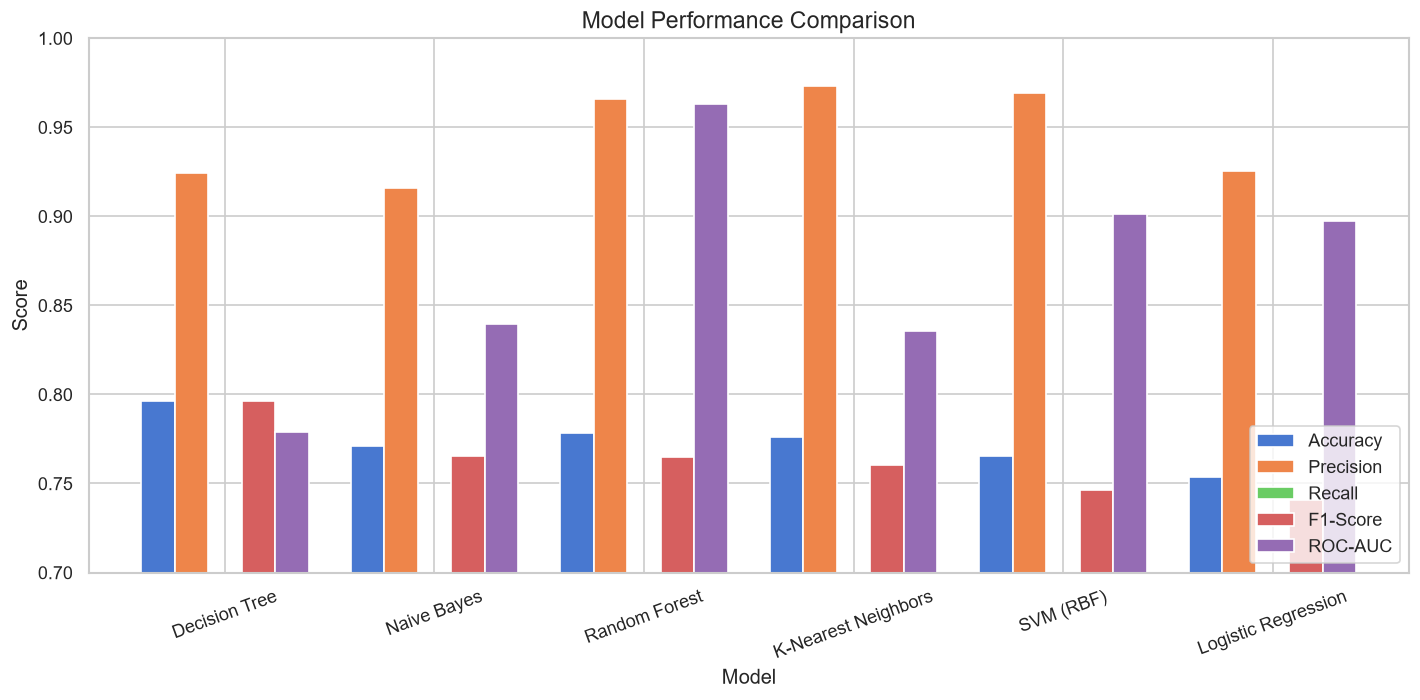

In [6]:
results_df.to_csv(OUT_DIR + 'model_comparison.csv', index=False)

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR + 'model_comparison.png', dpi=300)
plt.show()

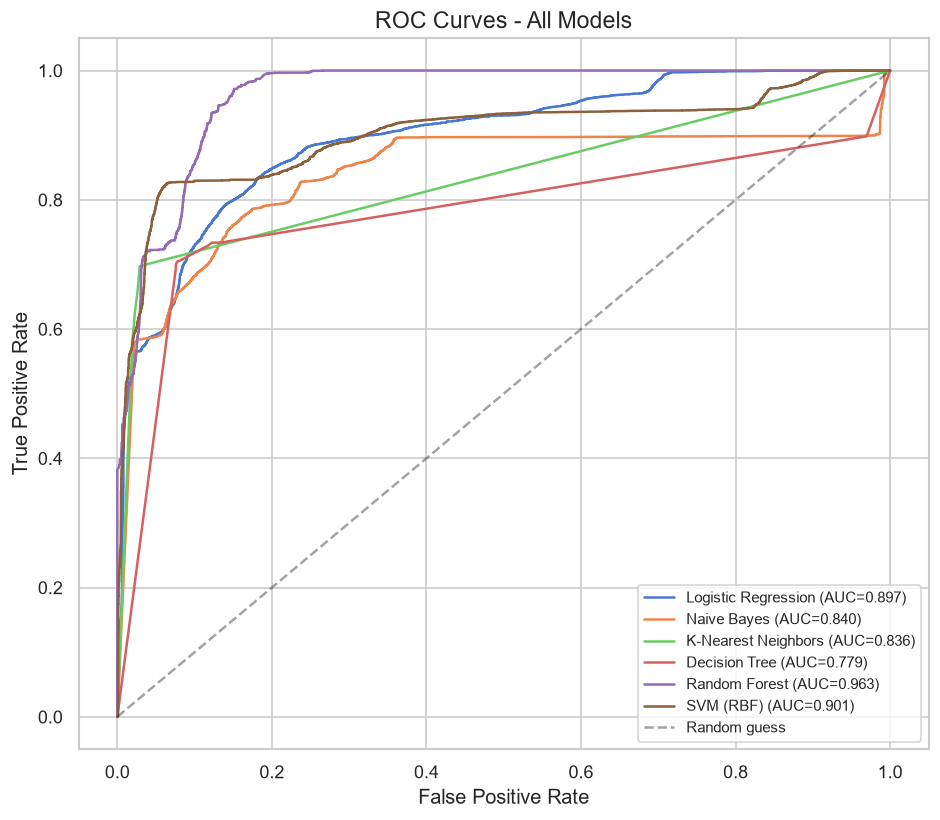

In [7]:
# ROC curves for all models
fig, ax = plt.subplots(figsize=(8, 7))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.loc[results_df['Model'] == name, 'ROC-AUC'].values[0]
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR + 'roc_curves.png', dpi=300)
plt.show()

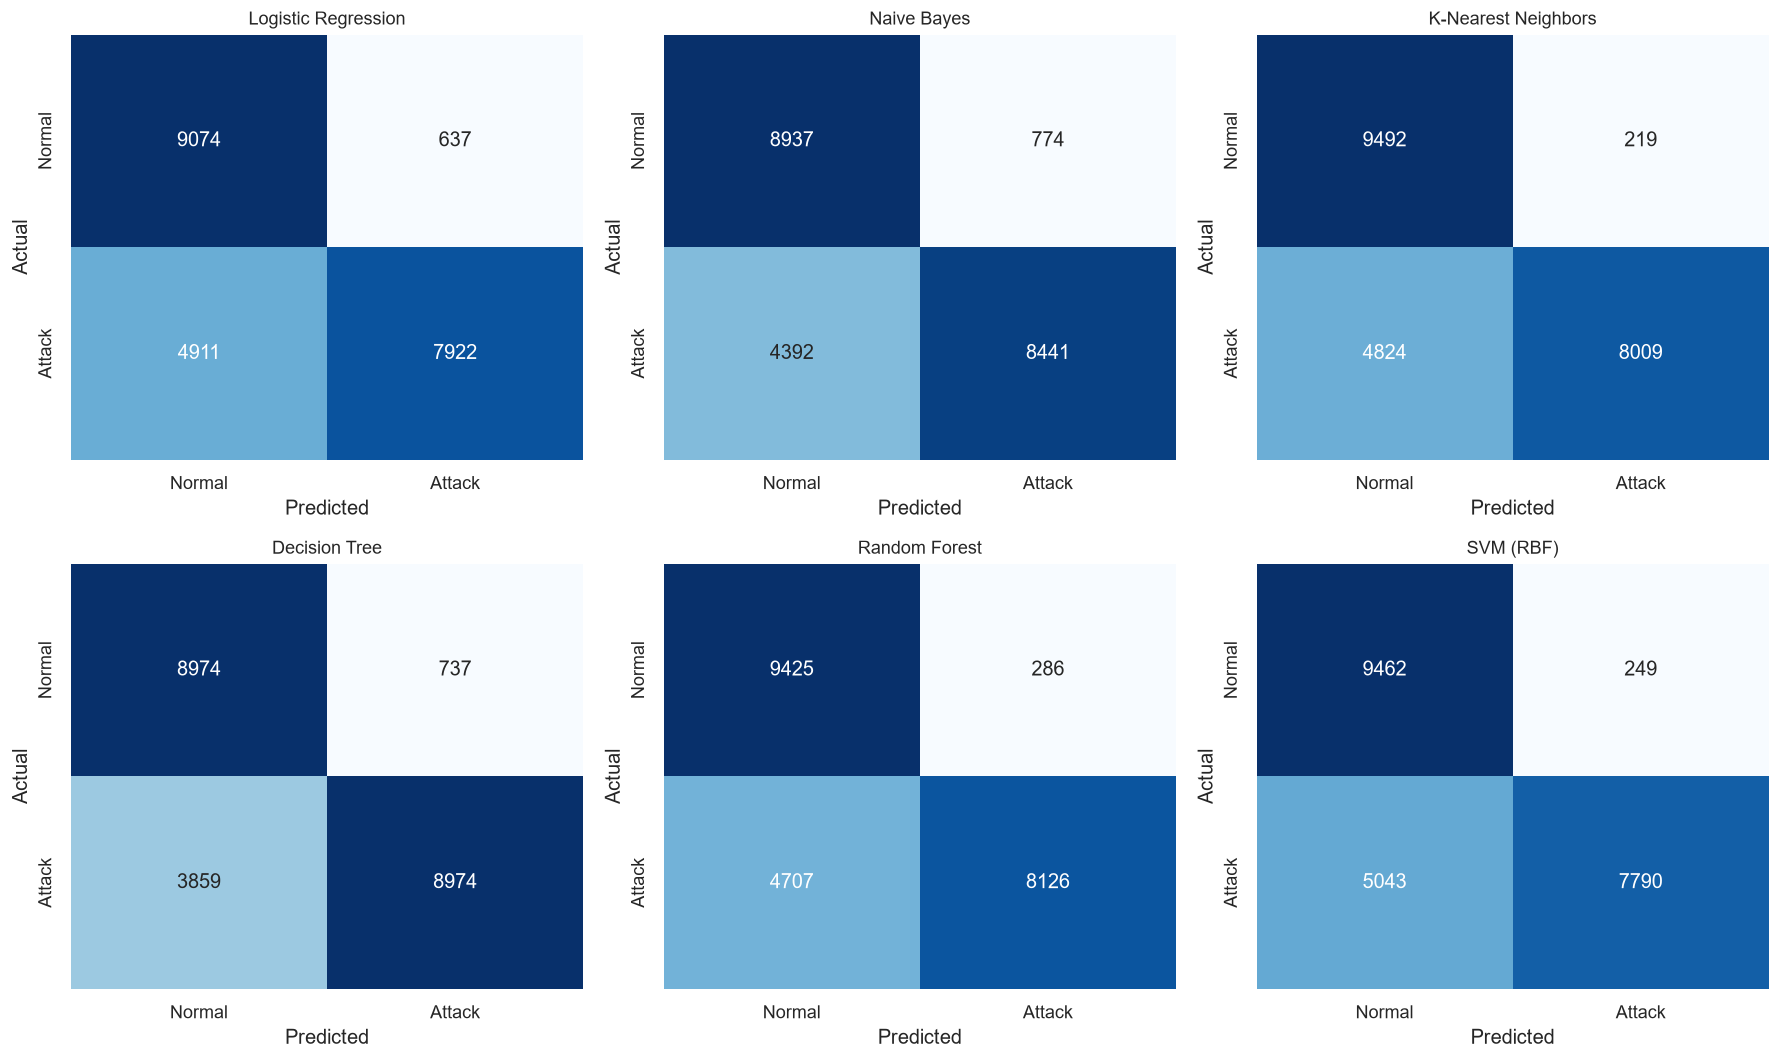

In [8]:
# Confusion matrices for all models
n_models = len(trained_models)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, model) in zip(axes.flat, trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'], cbar=False)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(FIG_DIR + 'confusion_matrices.png', dpi=300)
plt.show()

## 5. Select Best Model

For intrusion detection, **recall** is critical (missing an attack = false negative = dangerous). We rank primarily by F1-score (balances precision/recall) and report recall alongside it.

In [9]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f'Best model by F1-Score: {best_model_name}')
print(results_df.iloc[0])
print()
print(classification_report(y_test, best_model.predict(X_test), target_names=['Normal', 'Attack']))

Best model by F1-Score: Decision Tree
Model             Decision Tree
Accuracy               0.796132
Precision              0.924107
Recall                 0.699291
F1-Score               0.796132
ROC-AUC                0.778998
Train Time (s)             0.64
Name: 0, dtype: object

              precision    recall  f1-score   support

      Normal       0.70      0.92      0.80      9711
      Attack       0.92      0.70      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.81      0.81      0.80     22544
weighted avg       0.83      0.80      0.80     22544



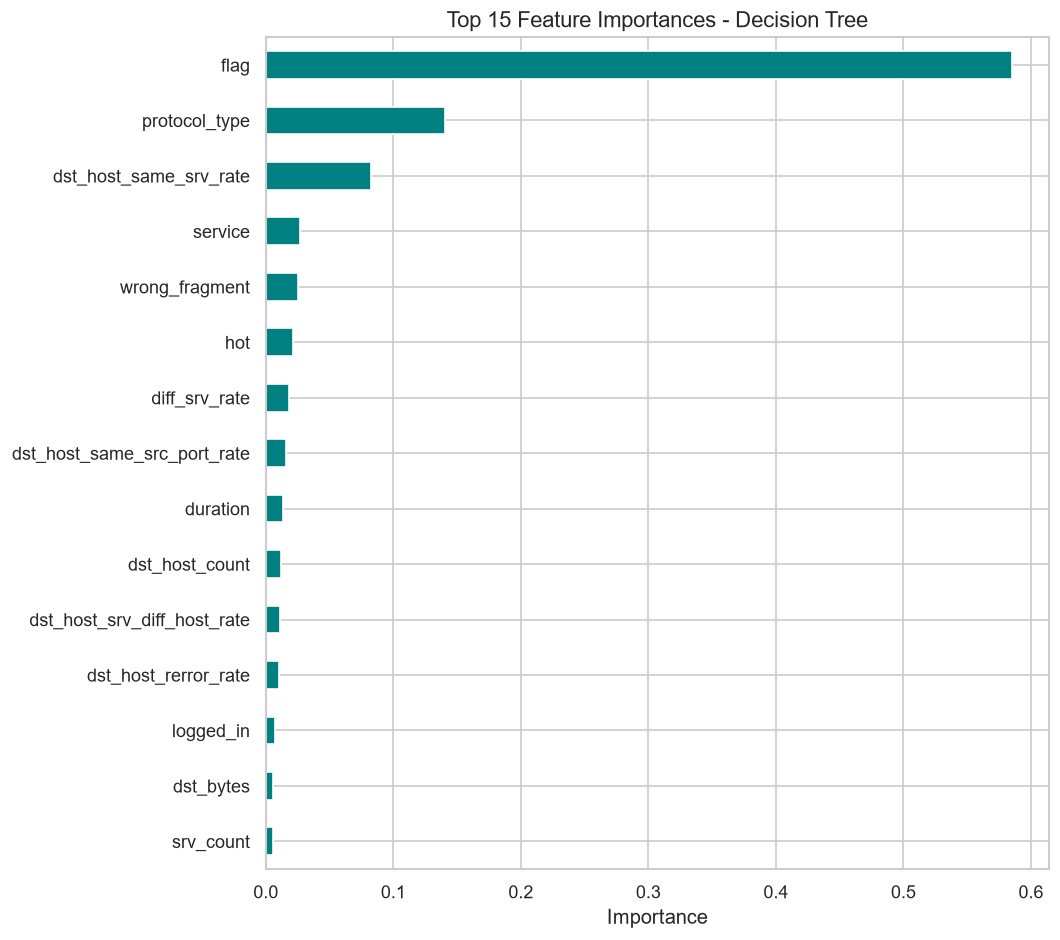

In [10]:
# Feature importance (only meaningful for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 8))
    importances.head(15).plot(kind='barh', ax=ax, color='teal')
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Feature Importances - {best_model_name}', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(FIG_DIR + 'feature_importance.png', dpi=300)
    plt.show()
else:
    print(f'{best_model_name} does not expose feature_importances_.')

## 6. Cross-Validation on Best Model

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Re-instantiate a fresh copy so cross_val_score does its own fitting
from sklearn.base import clone
cv_model = clone(best_model)

cv_X = X_train_svm if best_model_name == 'SVM (RBF)' else X_train
cv_y = y_train_svm if best_model_name == 'SVM (RBF)' else y_train

cv_scores = cross_val_score(cv_model, cv_X, cv_y, cv=cv, scoring='f1', n_jobs=-1)
print(f'5-fold CV F1-scores: {np.round(cv_scores, 4)}')
print(f'Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}')

5-fold CV F1-scores: [0.9966 0.9967 0.9959 0.9965 0.997 ]
Mean: 0.9966  Std: 0.0003


## 7. Save Best Model & Metadata

In [12]:
joblib.dump(best_model, MODEL_DIR + 'best_model.joblib')

metadata = {
    'best_model_name': best_model_name,
    'feature_columns': feature_cols,
    'categorical_columns': ['protocol_type', 'service', 'flag'],
    'metrics': results_df.iloc[0].to_dict(),
    'cv_f1_mean': float(cv_scores.mean()),
    'cv_f1_std': float(cv_scores.std()),
}
with open(MODEL_DIR + 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved models/best_model.joblib ({best_model_name})')
print('Saved models/model_metadata.json')
print()
print('All results saved to outputs/model_comparison.csv')
print('Figures saved to outputs/figures/')
print()
print('Next: run the Streamlit prototype (app.py) to test predictions interactively.')

Saved models/best_model.joblib (Decision Tree)
Saved models/model_metadata.json

All results saved to outputs/model_comparison.csv
Figures saved to outputs/figures/

Next: run the Streamlit prototype (app.py) to test predictions interactively.
